# Amazon Web Traffic Analysis — EDA
Data cleaning, exploratory analysis, and business insight generation using Python (pandas, matplotlib, seaborn).

## 1. Load raw data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/amazon_traffic_raw.csv")
print("Initial shape:", df.shape)
df.head()


Initial shape: (42815, 12)


In [ ]:
print(df.isnull().sum())


session_id                    0
timestamp                     0
country                       0
device_category             704
source                        0
page_path                     0
avg_session_duration_sec    701
bounce_rate                 735
conversions                   0
new_user                      0
page_views                    0
unique_page_views             0
dtype: int64


## 2. Data cleaning

In [ ]:
df["source"] = df["source"].astype(str).str.strip().str.title()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["device_category"] = df["device_category"].fillna(df["device_category"].mode()[0])
df["bounce_rate"] = df["bounce_rate"].fillna(df["bounce_rate"].median())
df["avg_session_duration_sec"] = df["avg_session_duration_sec"].fillna(df["avg_session_duration_sec"].median())
df = df.drop_duplicates()

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.to_period("M").astype(str)
print("Cleaned shape:", df.shape)


Cleaned shape: (42815, 15)


## 3. Traffic source performance

source
Organic Search    32.2
Direct            22.2
Paid Search       17.8
Social            13.9
Referral           8.8
Email              5.1
Name: proportion, dtype: float64


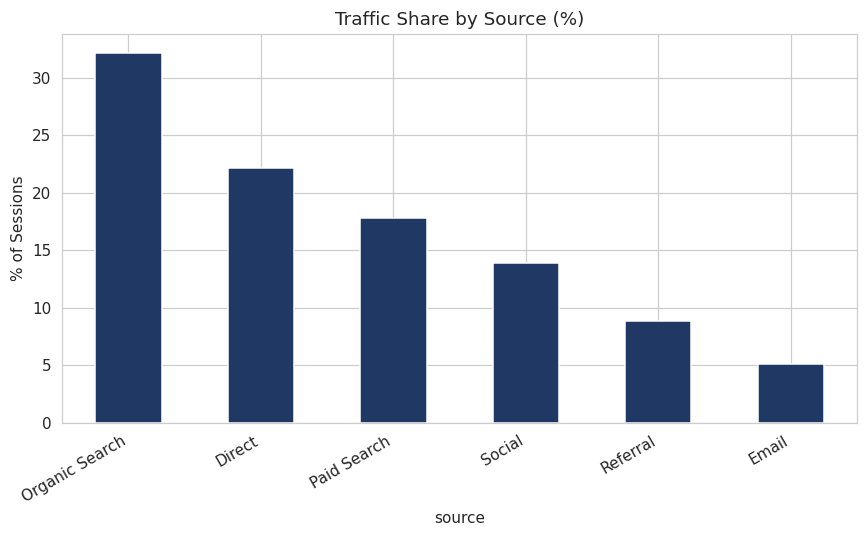

In [ ]:
source_traffic = df["source"].value_counts(normalize=True).mul(100).round(1)
print(source_traffic)

plt.figure(figsize=(8,5))
source_traffic.plot(kind="bar", color="#1F3864")
plt.title("Traffic Share by Source (%)")
plt.ylabel("% of Sessions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Conversion rate by source

source
Email             6.38
Direct            5.57
Paid Search       4.69
Organic Search    3.80
Referral          3.63
Social            2.06
Name: conversions, dtype: float64


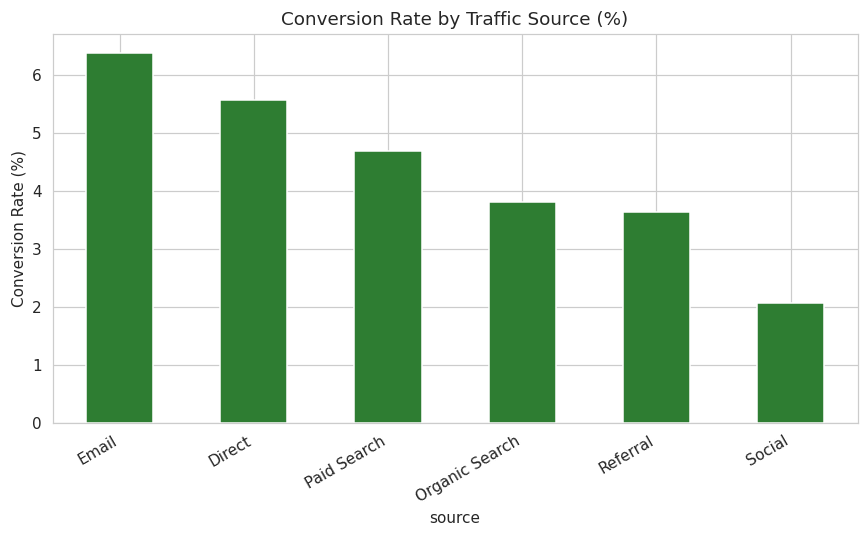

In [ ]:
conv_by_source = (df.groupby("source")["conversions"].mean() * 100).round(2).sort_values(ascending=False)
print(conv_by_source)

plt.figure(figsize=(8,5))
conv_by_source.plot(kind="bar", color="#2E7D32")
plt.title("Conversion Rate by Traffic Source (%)")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Insight:** Email and Direct traffic convert best despite lower volume; Social drives high traffic but the lowest conversion rate.

## 5. Bounce rate by device category

device_category
Desktop    38.0
Mobile     48.9
Tablet     45.1
Name: bounce_rate, dtype: float64


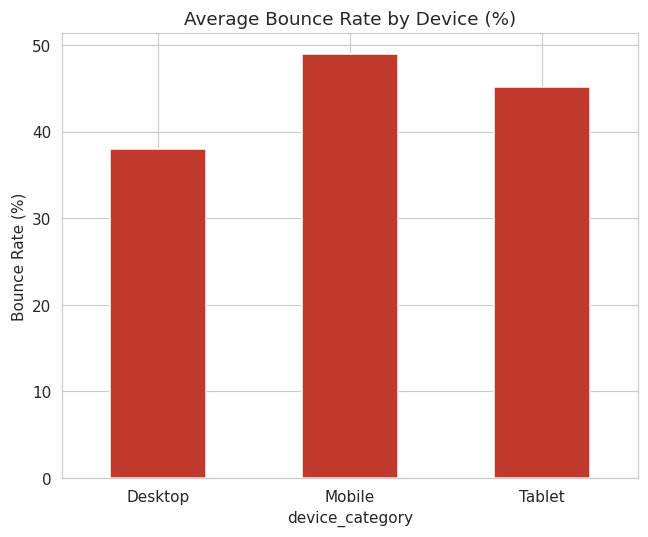

In [ ]:
bounce_by_device = (df.groupby("device_category")["bounce_rate"].mean() * 100).round(1)
print(bounce_by_device)

plt.figure(figsize=(6,5))
bounce_by_device.plot(kind="bar", color="#C0392B")
plt.title("Average Bounce Rate by Device (%)")
plt.ylabel("Bounce Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Top 10 countries by traffic

country
United States     12838
India              7676
United Kingdom     3824
Other              3499
Canada             3021
Germany            2537
Australia          2196
Brazil             2187
Japan              1728
Mexico             1662
Name: count, dtype: int64


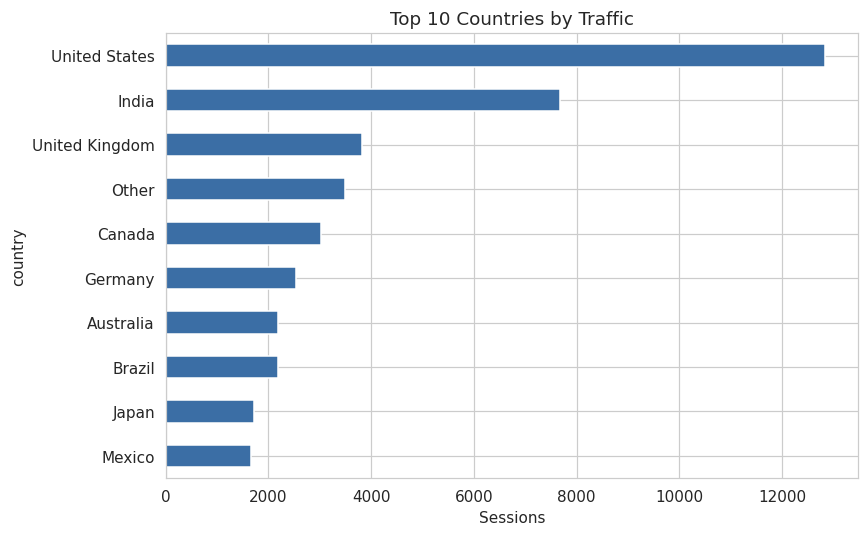

In [ ]:
top_countries = df["country"].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(8,5))
top_countries.plot(kind="barh", color="#3B6EA5")
plt.title("Top 10 Countries by Traffic")
plt.xlabel("Sessions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Traffic by hour of day

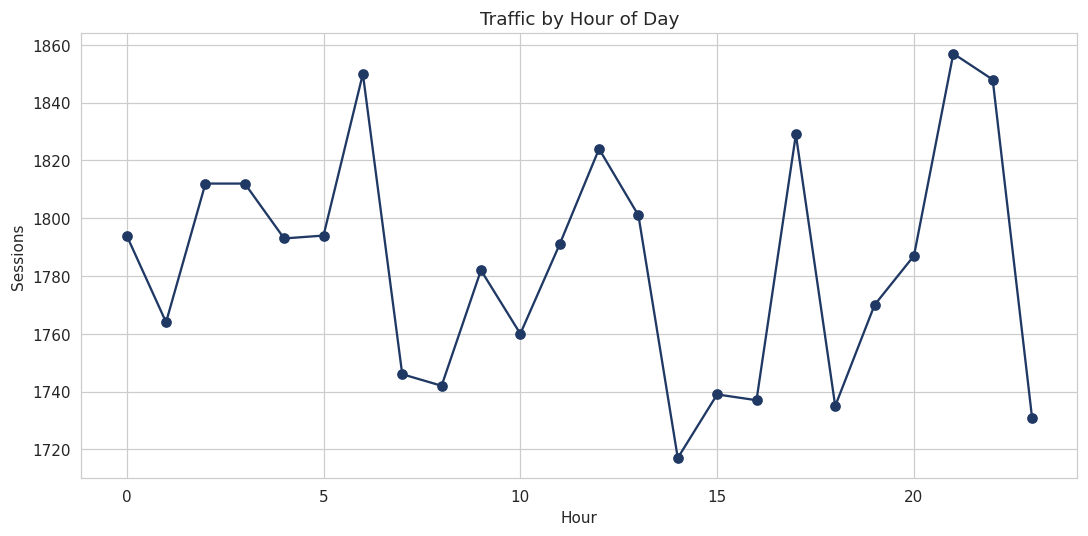

In [ ]:
hourly = df.groupby("hour").size()

plt.figure(figsize=(10,5))
hourly.plot(marker="o", color="#1F3864")
plt.title("Traffic by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Sessions")
plt.tight_layout()
plt.show()


## 8. Traffic by day of week

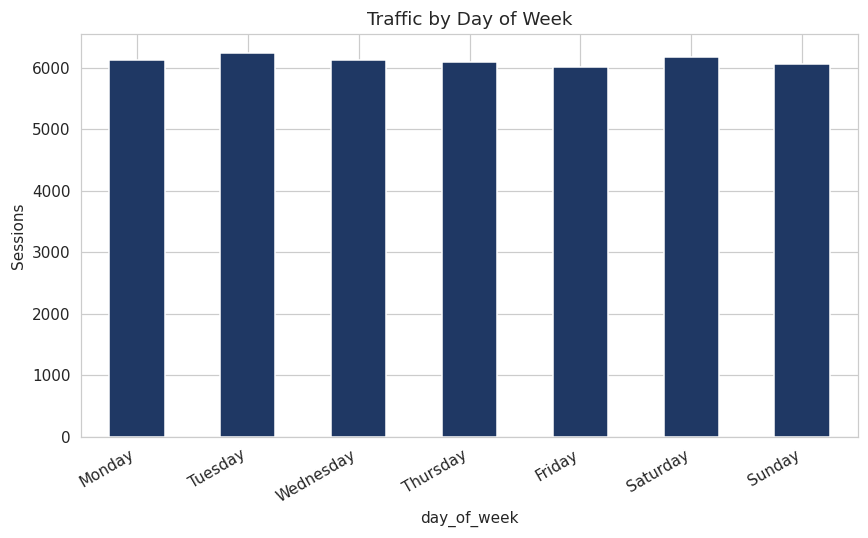

In [ ]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily = df["day_of_week"].value_counts().reindex(order)

plt.figure(figsize=(8,5))
daily.plot(kind="bar", color="#1F3864")
plt.title("Traffic by Day of Week")
plt.ylabel("Sessions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Monthly traffic trend

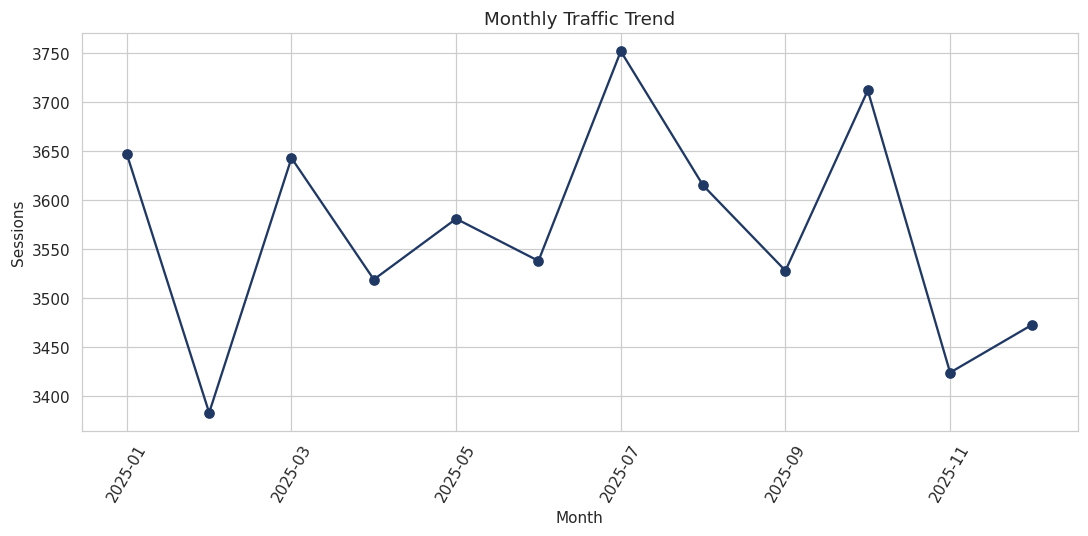

In [ ]:
monthly_traffic = df.groupby("month").size()

plt.figure(figsize=(10,5))
monthly_traffic.plot(marker="o", color="#1F3864")
plt.title("Monthly Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## Key Takeaways
- Organic Search drives the largest share of traffic, but Email and Direct traffic convert at the highest rates.
- Mobile has the highest bounce rate of all device categories — a strong signal to prioritize mobile UX improvements.
- Social traffic is high-volume but low-conversion, suggesting landing-page or targeting optimization opportunities.
- Traffic peaks at specific hours/days, useful for timing campaigns and promotions.